# 10 PCA Analysis

This notebook applies Principal Component Analysis (PCA) to the Spotify audio-feature dataset.

The goals are:
- reduce feature dimensionality
- identify major variance directions
- visualize tracks in lower-dimensional space
- prepare for scalable recommendation and clustering methods

## 1. Load Processed Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

In [3]:
processed_tracks = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "scaled_audio_features.csv"
)

processed_tracks.shape

(101939, 13)

In [4]:
processed_tracks.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity,track_name,track_id
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717,Blood,5qljLQuKnNJf4F4vfxQB0V
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047,The Ugly Duckling,3VAX2MJdmdqARLSU5hPMpm
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047,Jimmy Launches His Own Range Of Greetings Cards,1L3YAhsEMrGVvCgDXj2TYn
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513,The Crime At Pickets Mill,6aCe9zzoZmCojX7bbgKKtf
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490,Setup + Punchline = Joke,1Vo802A38tPFHmje1h91um


## 2. PCA Input Features

In [5]:
pca_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "duration_ms",
    "popularity"
]

In [6]:
X = processed_tracks[pca_features]

X.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms,popularity
0,-0.173579,0.630108,0.075031,-0.489350,-0.265923,0.325196,-0.504821,-0.110526,0.531880,-0.058745,-0.701717
1,1.525671,0.748269,-1.070377,-0.489359,0.315638,-0.141532,3.900983,-0.108640,0.405777,2.154023,-0.523047
2,1.188210,-0.675291,1.324219,-0.489359,4.221220,-0.668274,4.009186,-1.283537,-1.520172,1.292181,-0.523047
3,1.227033,0.748269,-1.769922,-0.489359,-0.482583,-1.740957,3.979676,-0.183184,0.191782,0.366578,-1.535513
4,1.247938,-0.709051,1.366499,-0.489359,4.101486,-0.691505,4.004267,-1.227456,-1.498773,1.638976,-0.463490


The PCA model is applied to the scaled numerical audio features. Since the variables were standardized beforehand, PCA can compare all features on the same scale.

## 3. Principal Component Analysis

In [7]:
pca = PCA()

pca_components = pca.fit_transform(X)

pca_components.shape

(101939, 11)

In [8]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.29498352, 0.1459689 , 0.10720937, 0.09213012, 0.0811777 ,
       0.07281346, 0.06769122, 0.05622609, 0.03711194, 0.03234113,
       0.01234656])

## 4. Explained Variance

In [9]:
variance_df = pd.DataFrame({
    "principal_component": range(1, len(explained_variance) + 1),
    "explained_variance": explained_variance
})

variance_df

,principal_component,explained_variance
0,1,0.294984
1,2,0.145969
2,3,0.107209
3,4,0.092130
4,5,0.081178
5,6,0.072813
6,7,0.067691
7,8,0.056226
8,9,0.037112
9,10,0.032341


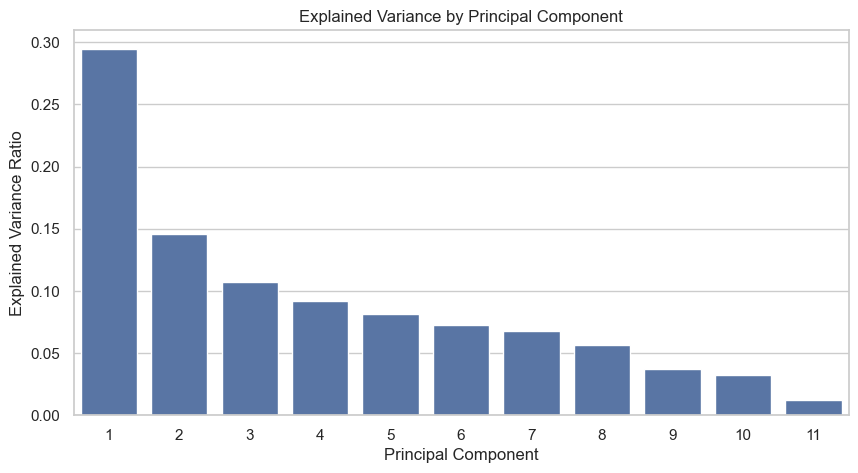

In [10]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=variance_df,
    x="principal_component",
    y="explained_variance"
)

plt.title("Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.show()

## 5. Cumulative Explained Variance

In [11]:
variance_df["cumulative_variance"] = (
    variance_df["explained_variance"]
    .cumsum()
)

variance_df

,principal_component,explained_variance,cumulative_variance
0,1,0.294984,0.294984
1,2,0.145969,0.440952
2,3,0.107209,0.548162
3,4,0.092130,0.640292
4,5,0.081178,0.721470
5,6,0.072813,0.794283
6,7,0.067691,0.861974
7,8,0.056226,0.918200
8,9,0.037112,0.955312
9,10,0.032341,0.987653


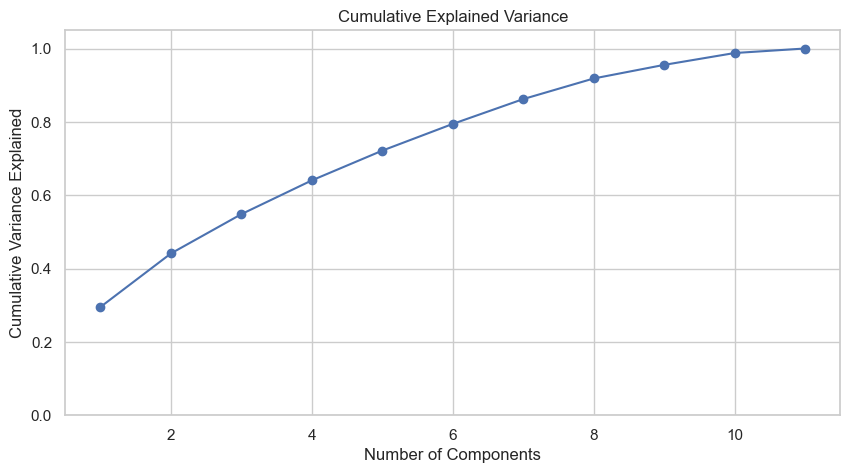

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    variance_df["principal_component"],
    variance_df["cumulative_variance"],
    marker="o"
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")

plt.ylim(0, 1.05)

plt.show()

# Final Interpretation

This notebook explored dimensionality reduction using Principal Component Analysis (PCA) on the standardized Spotify audio features dataset.

The PCA results showed that the original audio feature space can be compressed into a smaller number of components while still preserving most of the information contained in the data.

Key findings include:

- The first principal component explains approximately 29.5% of the total variance.
- The first 3 components together explain around 55% of the variance.
- The first 5 components explain approximately 72% of the variance.
- The first 8 components preserve more than 91% of the total variance.

The cumulative variance curve shows a noticeable elbow around components 5–6, suggesting that much of the important musical information can be represented using significantly fewer dimensions than the original feature set.

This is important for recommender systems because:

- lower-dimensional representations reduce computational complexity,
- similarity calculations become more efficient,
- noise and redundancy between correlated features can be reduced,
- and latent musical patterns become easier to capture.

The PCA analysis also confirms that several Spotify audio features are correlated and may represent broader hidden musical dimensions such as:
- energy and loudness,
- acousticness versus electronic intensity,
- or speech-oriented versus melodic content.

These reduced feature representations can later be used as inputs for:
- recommendation systems,
- similarity search,
- clustering approaches,
- and more advanced machine learning models.

Overall, PCA provides a strong foundation for building scalable and efficient music recommendation models in later project stages.